# BondSim Demonstration

This notebook shows how the **BondSim** synthetic corporate-bond market simulator works.

BondSim produces two outputs for each scenario:

- **Public trades** — fields an alpha researcher can use (price, side, notional, timestamps).
- **Truth ledger** — hidden state used to validate planted effects (never mixed into public output).

The simulator has three main stages:

1. **Event clock** — sparse Poisson-cluster Hawkes process for trade arrival times.
2. **Mark sampling** — notional, venue, and reporting-delay draws from empirical TRACE marks.
3. **Price engine** — fair-value random walk plus planted positive controls (reversal, sign persistence, lead-lag).

Run this notebook from the `bond_alpha` directory:

```bash
conda activate MechanicalAlpha
cd bond_alpha
jupyter notebook notebooks/bondsim_demo.ipynb
```

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    BOND_ALPHA_ROOT = NOTEBOOK_DIR.parent
else:
    BOND_ALPHA_ROOT = NOTEBOOK_DIR

SRC_ROOT = BOND_ALPHA_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.chdir(BOND_ALPHA_ROOT)

from bondsim.activity import daily_activity_multipliers, session_calendar
from bondsim.config import load_config
from bondsim.hawkes.graph import build_hawkes_graph
from bondsim.hawkes.simulate import simulate_session_clock
from bondsim.marks.fallback import EmpiricalMarkSampler
from bondsim.prices.engine import PriceEngine
from bondsim.scenarios import flags_for
from bondsim.schema import PUBLIC_TRADE_COLUMNS, TRUTH_COLUMNS
from bondsim.universe import build_universe
from bondsim.utils.seeds import SeedBank
from bondsim.validation.recovery import run_recovery_checks
from bondsim.visualization.hawkes import branching_mass_table

sns.set_theme(style="whitegrid")
print(f"Working directory: {BOND_ALPHA_ROOT}")

Working directory: /media/ak/10E1026C4FA6006E/GitRepos/MechanicalAlpha/bond_alpha


## 1. Configuration and scenarios

BondSim reads a YAML config. Scenarios toggle which **planted effects** are active:

| Scenario | Reversal | Sign persistence | Lead-lag |
|---|:---:|:---:|:---:|
| `controlled_all` | yes | yes | yes |
| `controlled_null` | no | no | no |
| `reversal_only` | yes | no | no |
| `sign_only` | no | yes | no |
| `leadlag_only` | no | no | yes |

Side convention (dealer perspective): `side = +1` means the client sells to the dealer; `side = -1` means the client buys.

In [2]:
config = load_config("configs/controlled_all.yaml")
seed_bank = SeedBank.create(config.project.master_seed)

scenario_rows = []
for scenario_name in [
    "controlled_all",
    "controlled_null",
    "reversal_only",
    "sign_only",
    "leadlag_only",
]:
    flags = flags_for(scenario_name)
    scenario_rows.append(
        {
            "scenario": scenario_name,
            "reversal": flags.reversal,
            "sign_persistence": flags.sign_persistence,
            "leadlag": flags.leadlag,
        }
    )

scenario_table = pd.DataFrame(scenario_rows)
scenario_table

,scenario,reversal,sign_persistence,leadlag
0,controlled_all,True,True,True
1,controlled_null,False,False,False
2,reversal_only,True,False,False
3,sign_only,False,True,False
4,leadlag_only,False,False,True


## 2. Synthetic universe

The simulator samples a bond universe from real TRACE statistics (or a fallback table when no processed data exist).
Each bond gets a target event rate, issuer membership, and leader/follower roles for lead-lag planting.

In [3]:
mode = "smoke"
universe = build_universe(pd.DataFrame(), config, seed_bank.rng("universe"), mode)

universe[[
    "synthetic_bond_id",
    "synthetic_issuer_id",
    "target_events_per_day",
    "is_issuer_leader",
    "is_leadlag_follower",
]].head(10)

,synthetic_bond_id,synthetic_issuer_id,target_events_per_day,is_issuer_leader,is_leadlag_follower
0,SB00000,SI0000,0.253461,False,True
1,SB00001,SI0001,3.244795,False,True
2,SB00002,SI0002,1.232743,False,True
3,SB00003,SI0000,1.708021,False,True
4,SB00004,SI0001,2.341892,False,True
5,SB00005,SI0002,4.665551,True,True
6,SB00006,SI0000,7.350388,True,False
7,SB00007,SI0001,15.781500,True,True
8,SB00008,SI0002,0.857348,False,True
9,SB00009,SI0000,0.544189,False,True


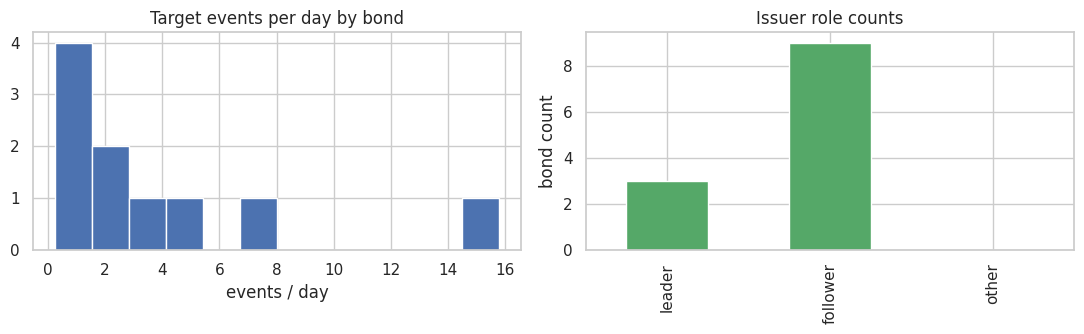

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(universe["target_events_per_day"], bins=12, color="#4c72b0", edgecolor="white")
axes[0].set_title("Target events per day by bond")
axes[0].set_xlabel("events / day")

role_counts = pd.Series(
    {
        "leader": int(universe["is_issuer_leader"].sum()),
        "follower": int(universe["is_leadlag_follower"].sum()),
        "other": int((~universe["is_issuer_leader"] & ~universe["is_leadlag_follower"]).sum()),
    }
)
role_counts.plot(kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("Issuer role counts")
axes[1].set_ylabel("bond count")

plt.tight_layout()
plt.show()

## 3. Hawkes event clock

Trade arrivals use a **sparse Poisson-cluster Hawkes** model:

- **Immigrants** — independent Poisson arrivals per bond, spread across intraday buckets.
- **Offspring** — each parent can spawn children on the same bond (same or opposite side) or on issuer siblings (lead-lag edges).
- Decay uses multiple half-lives (5, 30, 120 minutes by default).

When `sign_persistence` is enabled, same-side branching mass exceeds opposite-side mass.

In [5]:
scenario = "controlled_all"
flags = flags_for(scenario)
graph = build_hawkes_graph(universe, config, flags)

branching = branching_mass_table(
    graph.same_side_mass,
    graph.opposite_side_mass,
    graph.leader_follower_mass,
)
print(f"Spectral radius: {graph.spectral_radius:.4f} (must stay below {config.hawkes.maximum_spectral_radius})")
branching

Spectral radius: 0.2500 (must stay below 0.85)


,edge_class,mass
0,same_bond_same_side,0.20
1,same_bond_opposite_side,0.05
2,issuer_leader_to_follower,0.03


In [6]:
session_idx = 0
activity = daily_activity_multipliers(5, seed_bank.rng("activity"))
clock_events = simulate_session_clock(
    universe,
    graph,
    session_idx,
    float(activity[session_idx]),
    seed_bank.rng("hawkes_immigrants"),
    seed_bank.rng("hawkes_offspring"),
    config.simulation.max_events_per_session_safety,
)

clock_df = pd.DataFrame(
    [
        {
            "seconds": event.seconds,
            "bond": event.synthetic_bond_id,
            "side": event.side,
            "generation": event.generation,
            "edge_class": event.edge_class,
            "is_immigrant": event.is_immigrant,
            "cluster_id": event.cluster_id,
        }
        for event in clock_events
    ]
)
print(f"Session {session_idx}: {len(clock_df)} clock events")
clock_df.head()

Session 0: 59 clock events


,seconds,bond,side,generation,edge_class,is_immigrant,cluster_id
0,121.561672,SB00003,-1,0,immigrant,True,C0000_3_2
1,777.675649,SB00009,-1,1,issuer_leader_to_follower_same_side,False,C0000_3_2
2,1079.662044,SB00007,1,0,immigrant,True,C0000_7_2
3,1184.270690,SB00006,1,0,immigrant,True,C0000_6_5
4,1385.928377,SB00005,-1,0,immigrant,True,C0000_5_1


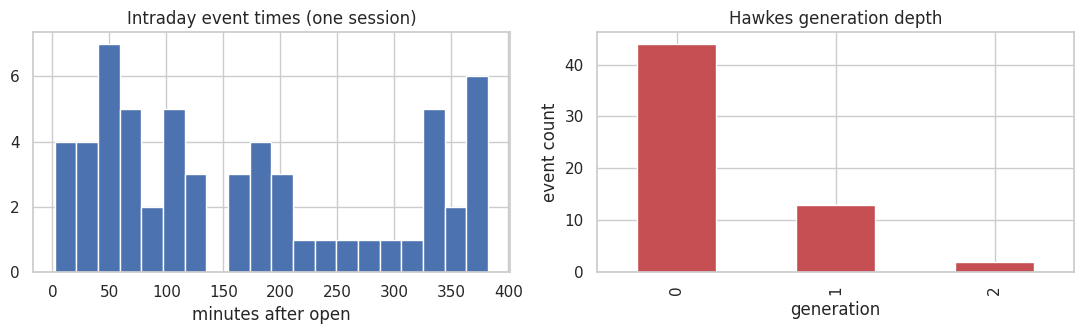

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

clock_df["minutes"] = clock_df["seconds"] / 60.0
axes[0].hist(clock_df["minutes"], bins=20, color="#4c72b0", edgecolor="white")
axes[0].set_title("Intraday event times (one session)")
axes[0].set_xlabel("minutes after open")

generation_counts = clock_df["generation"].value_counts().sort_index()
generation_counts.plot(kind="bar", ax=axes[1], color="#c44e52")
axes[1].set_title("Hawkes generation depth")
axes[1].set_xlabel("generation")
axes[1].set_ylabel("event count")

plt.tight_layout()
plt.show()

## 4. Mini end-to-end simulation

The next cell runs a compact smoke simulation without calling the full CLI pipeline.
It stitches together the Hawkes clock, empirical mark sampler, and price engine for a few sessions.

In [8]:
def synthetic_training_events(n_rows: int = 500) -> pd.DataFrame:
    """Build a minimal mark-training table when processed TRACE data are unavailable."""

    rng = np.random.default_rng(42)
    notionals = rng.lognormal(mean=12.5, sigma=0.8, size=n_rows)
    sides = rng.choice([1, -1], size=n_rows)
    return pd.DataFrame(
        {
            "side": sides,
            "notional": notionals,
            "is_interdealer": rng.choice([True, False], size=n_rows, p=[0.35, 0.65]),
            "trade_type": "customer",
            "venue": "unknown",
            "reporting_delay_ms": rng.exponential(250.0, size=n_rows),
            "log_notional": np.log1p(notionals),
        }
    )


def run_mini_simulation(
    scenario_name: str,
    n_sessions: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run a small BondSim session loop and return public trades and truth ledgers."""

    scenario_flags = flags_for(scenario_name)
    hawkes_graph = build_hawkes_graph(universe, config, scenario_flags)
    mark_sampler = EmpiricalMarkSampler(synthetic_training_events())
    price_engine = PriceEngine(universe, config, scenario_flags, seed_bank.rng("ou"))
    sessions = session_calendar("2026-01-02", n_sessions)
    activity = daily_activity_multipliers(n_sessions, seed_bank.rng("activity"))

    public_rows: list[dict[str, object]] = []
    truth_rows: list[dict[str, object]] = []

    immigrant_rng = seed_bank.rng("hawkes_immigrants")
    offspring_rng = seed_bank.rng("hawkes_offspring")
    mark_rng = seed_bank.rng("marks")

    for session_idx, session in enumerate(sessions):
        session_clock = simulate_session_clock(
            universe,
            hawkes_graph,
            session_idx,
            float(activity[session_idx]),
            immigrant_rng,
            offspring_rng,
            config.simulation.max_events_per_session_safety,
        )
        for event_idx, clock_event in enumerate(session_clock):
            event_id = f"{scenario_name}_{session_idx:04d}_{event_idx:06d}"
            mark = mark_sampler.sample(clock_event.side, mark_rng)
            public, truth = price_engine.price_event(clock_event, mark, event_id)
            timestamp = (
                pd.Timestamp(session)
                + pd.Timedelta(hours=9, minutes=30)
                + pd.Timedelta(clock_event.seconds, unit="s")
            )
            public.update(
                {
                    "timestamp_utc": timestamp,
                    "session_date": str(pd.Timestamp(session).date()),
                    "synthetic_bond_id": clock_event.synthetic_bond_id,
                    "synthetic_issuer_id": clock_event.synthetic_issuer_id,
                }
            )
            truth.update(
                {
                    "scenario": scenario_name,
                    "timestamp_utc": timestamp,
                    "session_date": str(pd.Timestamp(session).date()),
                    "hawkes_cluster_id": clock_event.cluster_id,
                    "hawkes_parent_event_id": clock_event.parent_event_id,
                    "hawkes_generation": clock_event.generation,
                    "hawkes_edge_class": clock_event.edge_class,
                    "is_immigrant": clock_event.is_immigrant,
                }
            )
            public_rows.append(public)
            truth_rows.append(truth)

    trades = pd.DataFrame(public_rows).loc[:, PUBLIC_TRADE_COLUMNS]
    truth = pd.DataFrame(truth_rows).loc[:, TRUTH_COLUMNS]
    return trades, truth


mini_trades, mini_truth = run_mini_simulation("controlled_all", n_sessions=8)
print(f"Mini simulation: {len(mini_trades):,} public trades, {len(mini_truth):,} truth rows")
mini_trades.head()

Mini simulation: 350 public trades, 350 truth rows


/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will 

,event_id,timestamp_utc,session_date,synthetic_bond_id,synthetic_issuer_id,side,notional,price,is_interdealer,trade_type,venue_bucket,reporting_delay_ms,currency
0,controlled_all_0000_000000,2026-01-02 09:32:01.561672248,2026-01-02,SB00003,SI0000,-1,345654.641407,103.050589,False,customer,unknown,60.616409,USD
1,controlled_all_0000_000001,2026-01-02 09:38:32.800652723,2026-01-02,SB00006,SI0000,-1,506195.272654,103.068047,False,customer,unknown,615.420017,USD
2,controlled_all_0000_000002,2026-01-02 09:42:57.675648748,2026-01-02,SB00009,SI0000,-1,70280.780248,102.678473,False,customer,unknown,1024.983231,USD
3,controlled_all_0000_000003,2026-01-02 09:49:29.006805000,2026-01-02,SB00007,SI0001,-1,227669.422320,98.526272,False,customer,unknown,164.765064,USD
4,controlled_all_0000_000004,2026-01-02 10:09:53.973406457,2026-01-02,SB00003,SI0000,1,517323.032955,103.038110,False,customer,unknown,1157.152167,USD


## 5. Planted effects in the truth ledger

The price engine maintains separate state components. Public prices observe concession and noise, but the truth ledger records planted contributions:

- **Large-print reversal** — temporary price impact that mean-reverts after large trades.
- **Leader-follower** — leader trades push follower fair values within the same issuer.
- **Sign persistence** — Hawkes branching bias toward same-side follow-on trades.

Planted effect event counts:
effect
leader_follower                         242
large_print_reversal,leader_follower     15
large_print_reversal                      7


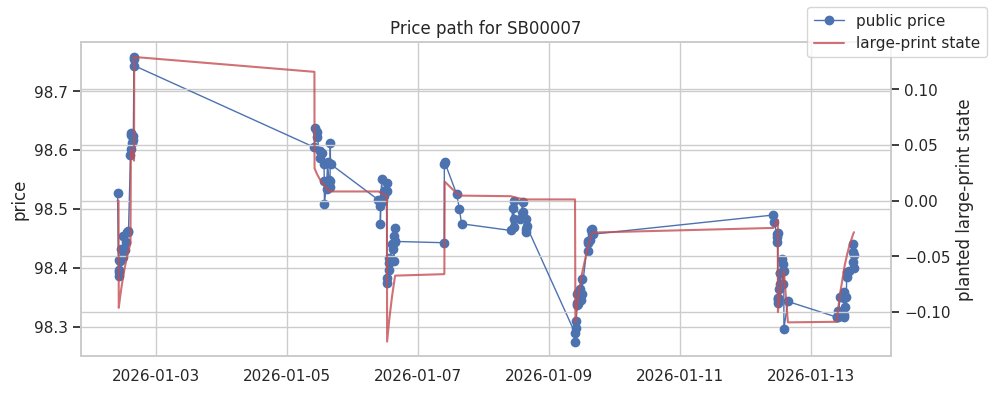

In [9]:
planted = mini_truth[mini_truth["planted_effect_ids"].astype(str).str.len() > 0].copy()
planted["effect"] = planted["planted_effect_ids"].astype(str)

effect_counts = planted["effect"].value_counts()
print("Planted effect event counts:")
print(effect_counts.to_string())

sample_bond = mini_trades["synthetic_bond_id"].value_counts().idxmax()
bond_trades = mini_trades[mini_trades["synthetic_bond_id"] == sample_bond].merge(
    mini_truth[["event_id", "planted_large_print_state", "planted_leadlag_state"]],
    on="event_id",
)
bond_trades = bond_trades.sort_values("timestamp_utc")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bond_trades["timestamp_utc"], bond_trades["price"], marker="o", linewidth=1, label="public price")
ax2 = ax.twinx()
ax2.plot(
    bond_trades["timestamp_utc"],
    bond_trades["planted_large_print_state"],
    color="#c44e52",
    alpha=0.8,
    label="large-print state",
)
ax.set_title(f"Price path for {sample_bond}")
ax.set_ylabel("price")
ax2.set_ylabel("planted large-print state")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 6. Recovery checks

Recovery functions estimate planted effects from public data (and truth for oracle checks).
A controlled scenario should pass; a null scenario should not show the same directional signals.

In [10]:
def recovery_summary(trades: pd.DataFrame, truth: pd.DataFrame, label: str) -> pd.DataFrame:
    report = run_recovery_checks(trades, truth, horizon="4h")
    rows = pd.DataFrame(report["results"])
    rows.insert(0, "scenario_run", label)
    rows.insert(1, "all_passed", report["passed"])
    return rows


null_trades, null_truth = run_mini_simulation("controlled_null", n_sessions=8)

recovery_table = pd.concat(
    [
        recovery_summary(mini_trades, mini_truth, "controlled_all"),
        recovery_summary(null_trades, null_truth, "controlled_null"),
    ],
    ignore_index=True,
)
recovery_table[["scenario_run", "all_passed", "name", "estimate", "expected_sign", "passed", "detail"]]

/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will 

/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)
/tmp/ipykernel_1072634/2760648189.py:56: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(hours=9, minutes=30)


,scenario_run,all_passed,name,estimate,expected_sign,passed,detail
0,controlled_all,True,reversal,-0.089914,-1,True,customer-side signed future price move after p...
1,controlled_all,True,sign_persistence,0.041176,1,True,next same-bond event same-side probability min...
2,controlled_all,True,leadlag,0.034701,1,True,same-issuer follower signed price response aft...
3,controlled_null,False,reversal,NaN,-1,False,no planted large-print events
4,controlled_null,False,sign_persistence,-0.004732,1,False,next same-bond event same-side probability min...
5,controlled_null,False,leadlag,NaN,1,False,no planted leader events


## 7. Loading a pre-generated medium run

The CLI writes partitioned parquet files under `data/medium/`. If a run exists locally, we can load it directly instead of re-simulating.

In [11]:
def read_partitioned_dataset(root: Path) -> pd.DataFrame:
    """Read monthly parquet partitions. Uses DuckDB because zstd partitions may fail in pyarrow."""

    files = sorted(root.glob("year=*/month=*/part-*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet partitions under {root}")

    import duckdb

    pattern = str(root / "year=*/month=*/part-*.parquet")
    return duckdb.read_parquet(pattern).df()


medium_root = BOND_ALPHA_ROOT / "data/medium/seed=20260834/synthetic/scenario=controlled_all"
medium_truth_root = BOND_ALPHA_ROOT / "data/medium/seed=20260834/synthetic_truth/scenario=controlled_all"

medium_trades: pd.DataFrame | None = None
medium_truth: pd.DataFrame | None = None

if medium_root.exists():
    try:
        medium_trades = read_partitioned_dataset(medium_root / "trades")
        medium_truth = read_partitioned_dataset(medium_truth_root / "event_truth")
        medium_bonds = pd.read_parquet(medium_root / "bonds.parquet", engine="pyarrow")
        manifest = json.loads((medium_root / "manifest.json").read_text())
        print(
            f"Loaded medium run: {manifest['rows']['public']:,} trades "
            f"across {manifest['rows']['bonds']} bonds"
        )
        medium_trades.head()
    except Exception as error:
        print(f"Could not load medium run ({error}). The mini simulation above still demonstrates BondSim.")
else:
    print("No pre-generated medium run found. Use the mini simulation above or run:")
    print("  python -m bondsim pipeline --config configs/controlled_all.yaml --mode smoke --force")

Could not load medium run (Repetition level histogram size mismatch). The mini simulation above still demonstrates BondSim.


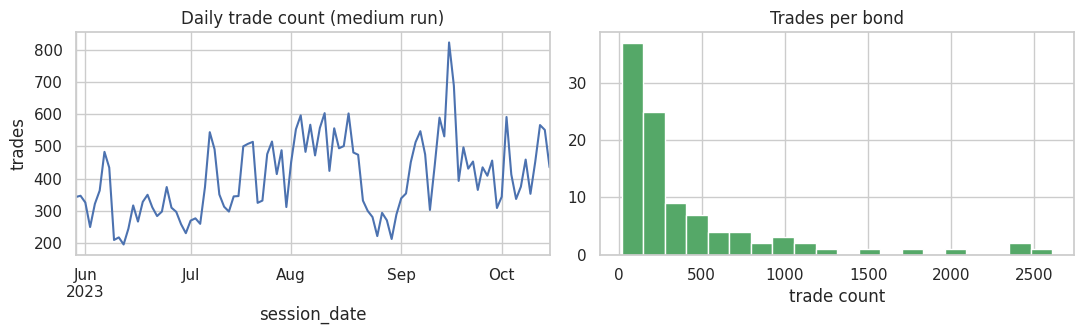

In [12]:
if medium_trades is not None and medium_truth is not None:
    medium_trades["timestamp_utc"] = pd.to_datetime(medium_trades["timestamp_utc"], utc=True)
    medium_trades["session_date"] = pd.to_datetime(medium_trades["session_date"])

    daily_counts = medium_trades.groupby("session_date").size()
    events_per_bond = medium_trades.groupby("synthetic_bond_id").size()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    daily_counts.plot(ax=axes[0], color="#4c72b0")
    axes[0].set_title("Daily trade count (medium run)")
    axes[0].set_ylabel("trades")

    axes[1].hist(events_per_bond, bins=20, color="#55a868", edgecolor="white")
    axes[1].set_title("Trades per bond")
    axes[1].set_xlabel("trade count")

    plt.tight_layout()
    plt.show()

    medium_recovery = run_recovery_checks(medium_trades, medium_truth, horizon="1D")
    pd.DataFrame(medium_recovery["results"])[["name", "estimate", "passed", "detail"]]
else:
    print("Skipping medium-run plots because no medium dataset was loaded.")

## 8. Running the full CLI pipeline

For production-shaped output (partitioned parquet, manifests, validation reports), use the CLI from `bond_alpha`:

```bash
conda activate MechanicalAlpha
export PYTHONPATH=src

# Smoke mode: 10 bonds, 20 sessions
python -m bondsim pipeline --config configs/controlled_all.yaml --mode smoke --force

# Validate an existing scenario
python -m bondsim validate --config configs/controlled_all.yaml --mode smoke
```

Outputs land in:

- `data/synthetic/scenario=<name>/` — public trades and bonds
- `data/synthetic_truth/scenario=<name>/` — hidden truth ledger
- `reports/` — validation summaries and fidelity plots

Alpha factor code in `mechanical_alpha` should consume only the public bundle, never the truth tables.